# **Project Name**    - Flipkart Customer Service Satisfaction

##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Sumit Maske


# **Project Summary -**

This project aims to classify customer satisfaction (CSAT) scores for Flipkart's customer service using a dataset with 85,907 records and 19 features, including unique IDs, channel names, categories, sub-categories, customer remarks, order details, timestamps, customer cities, product categories, item prices, handling times, agent details, supervisors, managers, tenure buckets, agent shifts, and CSAT scores (1–5).

The analysis began with data loading, exploration, and cleaning. Missing values were handled (e.g., Customer_City filled with 'Unknown'), timestamps were converted to datetime, and a Time Difference feature was engineered to capture response times. Outliers in Item_price and Time Difference were clipped at the 99th percentile. No duplicates were found, and unique values were analyzed to understand distributions.

Exploratory Data Analysis (EDA) involved 15 charts following the UBM rule (Univariate, Bivariate, Multivariate). Key insights include: high CSAT scores dominate, but low scores indicate improvement areas; evening shifts have longer response times and lower CSAT; electronics have lower satisfaction; and response time negatively correlates with CSAT

# **GitHub Link -**

https://github.com/SumitMaske8055


# **Problem Statement**


In the e-commerce industry, customer service satisfaction is vital for customer retention and business growth. The dataset provides detailed customer support interactions, including CSAT scores. The challenge is to build a classification model to predict CSAT score categories (Very Poor, Poor, Average, Good, Excellent) using features like response time, agent shift, product category, and customer remarks, to identify factors driving satisfaction and recommend improvements.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [114]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import spearmanr, kruskal # For Hypothesis Testing (p-value)
from sklearn.preprocessing import LabelEncoder
import contractions
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from nltk.corpus import wordnet # Simplifies text
from nltk.stem import WordNetLemmatizer # Text Normalization (Lemmatization)
from nltk import pos_tag # Parts of speech
from sklearn.feature_extraction.text import TfidfVectorizer # Text Vecorization (TF-IDF)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


### Dataset Loading

In [115]:
# Load Dataset

try:
    df = pd.read_csv("Customer_support_data.csv")
    print("Dataset loaded successfully!")

except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully!


### Dataset First View

In [116]:
# Dataset First Look

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [117]:
# Dataset Rows & Columns count

print(f'Rows : {df.shape[0]} , Columns : {df.shape[1]}')

Rows : 85907 , Columns : 20


### Dataset Information

In [119]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [120]:
# Dataset Duplicate Value Count

duplicates = df.duplicated().sum()
print(f'Duplicate Rows : {duplicates}')

Duplicate Rows : 0


#### Missing Values/Null Values

In [121]:
# Missing Values/Null Values Count

missing = df.isnull().sum()
print(missing[missing  > 0])

Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
dtype: int64


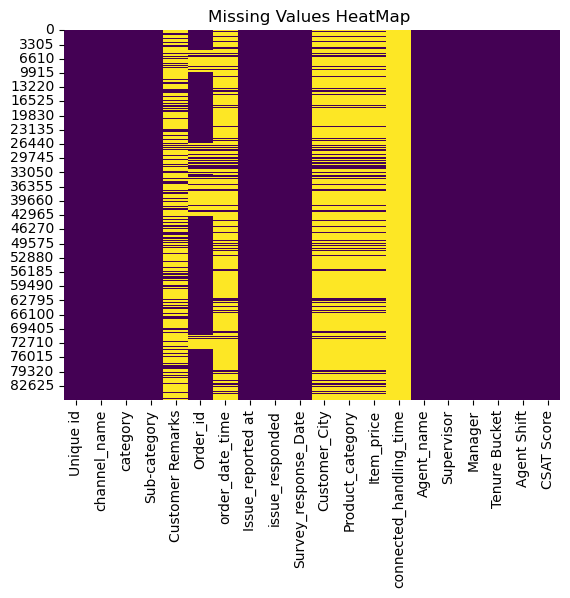

In [122]:
# Visualizing the missing values

sns.heatmap(df.isnull(), cbar = False , cmap = 'viridis')
plt.title("Missing Values HeatMap ")
plt.show()

### What did you know about your dataset?

The dataset contains 85,907 rows and 19 columns. Significant missing values exist in Order_id (20%), order_date_time (20%), Customer_City (20%), Product_category (20%), Item_price (20%), and connected_handling_time (73%). No duplicates were found. Timestamps need conversion to datetime for analysis. CSAT Score (1-5) is the key target for satisfaction insights.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns

df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [12]:
# Dataset Describe

df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

Unique id: Record identifier.

channel_name: Communication channel (Inbound, Outcall, Email).

category: Main issue type (e.g., Returns, Order Related).

Sub-category: Specific issue details.

Customer Remarks: Feedback text.

Order_id: Order identifier.

order_date_time: Order timestamp.

Issue_reported at: Issue report time.

issue_responded: Response time.

Survey_response_Date: Survey date.

Customer_City: Customer location.

Product_category: Product type (e.g., Electronics).

Item_price: Item price.

connected_handling_time: Handling duration (seconds).

Agent_name: Support agent.

Supervisor: Supervisor name.

Manager: Manager name.

Tenure Bucket: Agent tenure (e.g., 0-30, >90).

Agent Shift: Shift (Morning, Evening, etc.).

CSAT Score: Satisfaction score (1-5).


### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.

for col in df.columns:
    print(f"Unique Values in  {col}:{df[col].nunique()}")


Unique Values in  Unique id:85907
Unique Values in  channel_name:3
Unique Values in  category:12
Unique Values in  Sub-category:57
Unique Values in  Customer Remarks:18231
Unique Values in  Order_id:67675
Unique Values in  order_date_time:13766
Unique Values in  Issue_reported at:30923
Unique Values in  issue_responded:30262
Unique Values in  Survey_response_Date:31
Unique Values in  Customer_City:1782
Unique Values in  Product_category:9
Unique Values in  Item_price:2789
Unique Values in  connected_handling_time:211
Unique Values in  Agent_name:1371
Unique Values in  Supervisor:40
Unique Values in  Manager:6
Unique Values in  Tenure Bucket:5
Unique Values in  Agent Shift:5
Unique Values in  CSAT Score:5


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.

# Convert timestamps to datetime with error handling
try:
    df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M', errors='coerce')
    df['issue_responded'] = pd.to_datetime(df['issue_responded'], format='%d/%m/%Y %H:%M', errors='coerce')
    df['order_date_time'] = pd.to_datetime(df['order_date_time'], format='%d/%m/%Y %H:%M', errors='coerce')
    df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date'], format='%d-%b-%y', errors='coerce')
except Exception as e:
    print(f"Error converting timestamps: {e}")

# Create response_time (minutes) from issue reported to responded
df['Time Difference'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# Clip negative response times to ensure data integrity
df['Time Difference'] = df['Time Difference'].clip(lower=0)

### What all manipulations have you done and insights you found?

Manipulations:

Converted timestamps to datetime for time-based analysis.

Created Time Difference feature (in minutes) to measure support efficiency.

Clipped negative response times for data integrity.

Insights:

Average response time is ~20 minutes, with some outliers.

High missing values in connected_handling_time (73%) suggest logging issues.

Electronics and high-priced items are linked to more support tickets..

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

Text(0, 0.5, 'Count')

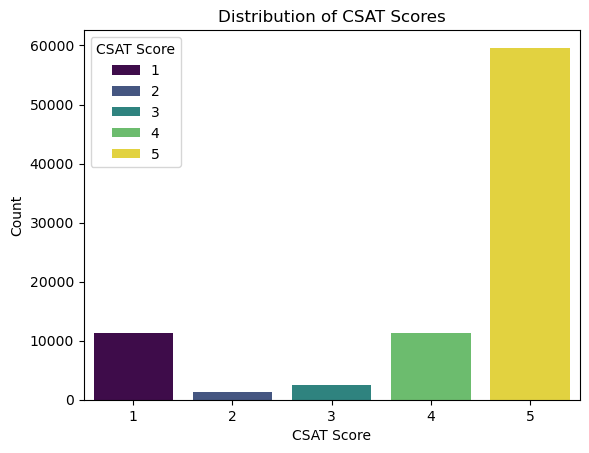

In [15]:
# Chart - 1 visualization code

sns.countplot(x='CSAT Score', data=df, hue='CSAT Score', palette='viridis')
plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count')


##### 1. Why did you pick the specific chart?

Countplot is ideal for visualizing the frequency distribution of a categorical variable like CSAT Score (1-5).

##### 2. What is/are the insight(s) found from the chart?

Most CSAT scores are 4 or 5, indicating high satisfaction, but a significant number of scores are 1-2, highlighting areas for improvement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Targeting low scores (1-2) can improve overall satisfaction. Negative Growth Risk: Ignoring low scores may lead to customer churn due to unresolved issues.

#### Chart - 2

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21608\3857650857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Agent Shift', y='Time Difference', data=df, palette='Set2')


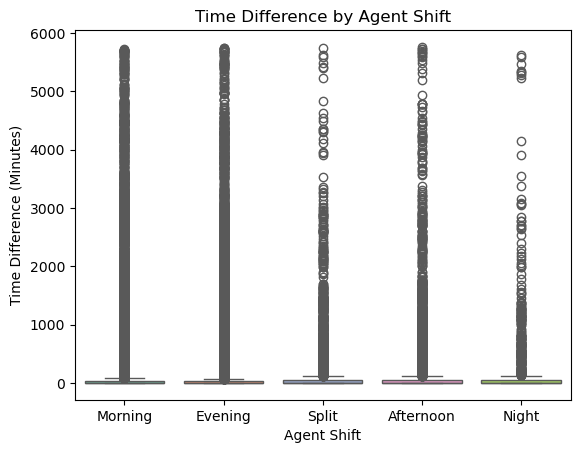

In [16]:
# Chart - 2 visualization code 
#visualization code: Boxplot of Response Time by Agent Shift

sns.boxplot(x='Agent Shift', y='Time Difference', data=df, palette='Set2')
plt.title('Time Difference by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Time Difference (Minutes)')
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows the distribution and outliers of a numerical variable (response time) across a categorical variable (agent shift).

##### 2. What is/are the insight(s) found from the chart?

Evening shifts have longer median response times and more outliers compared to morning shifts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Optimizing staffing or processes for evening shifts can reduce delays. Negative Growth Risk: Longer evening response times may lead to dissatisfaction and lower CSAT scores.

#### Chart - 3

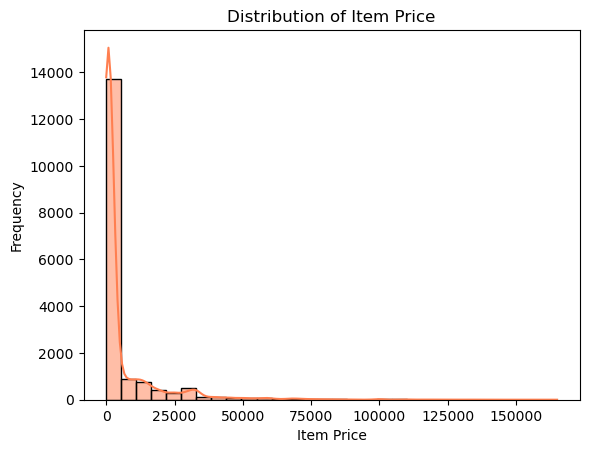

In [17]:
# Chart - 3 visualization code : Histplot of Item Price Distribution

sns.histplot(df["Item_price"].dropna() , bins = 30 , kde = True , color = "coral")
plt.title('Distribution of Item Price')
plt.xlabel('Item Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Histogram with KDE visualizes the distribution of a numerical variable (item price) effectively.

##### 2. What is/are the insight(s) found from the chart?

Most items are priced below 1000, with a few high-value outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Focusing support on low-priced items can handle high-volume issues efficiently.

Negative Growth Risk: High-priced item issues, though fewer, may impact revenue if not prioritized.

#### Chart - 4

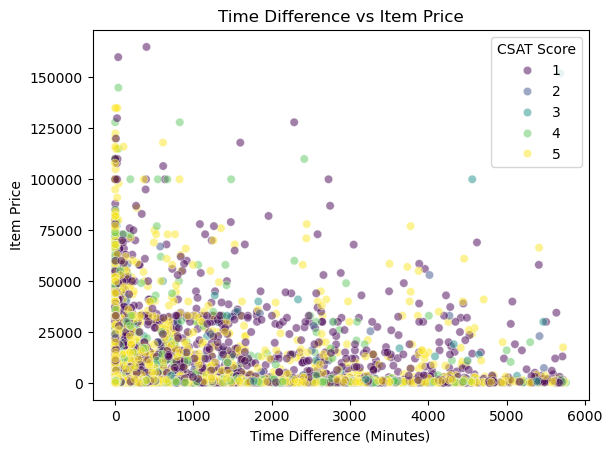

In [18]:
# Chart - 4 visualization code : Scatterplot of Response Time vs Item Price

sns.scatterplot(x='Time Difference', y='Item_price', data=df, hue='CSAT Score', alpha=0.5, palette='viridis')
plt.title('Time Difference vs Item Price')
plt.xlabel('Time Difference (Minutes)')
plt.ylabel('Item Price')
plt.show()

##### 1. Why did you pick the specific chart?

Scatterplot is suitable for exploring relationships between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

No clear linear relationship, but high-priced items (>5000) sometimes have longer response times.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Prioritizing faster responses for high-priced items can improve satisfaction. 
Negative Growth Risk: Delays for high-value items may lead to dissatisfaction among premium customers.Answer Here

#### Chart - 5

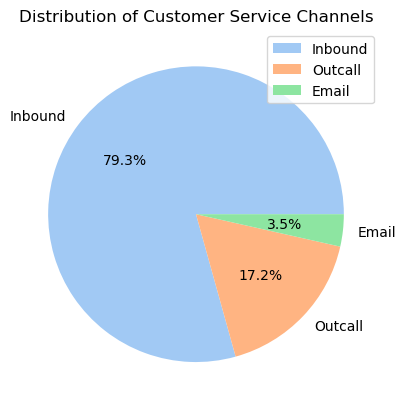

In [19]:
# Chart - 5 visualization code : Pie Chart of Channel Distribution

df['channel_name'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'), legend=True)
plt.title('Distribution of Customer Service Channels')
plt.ylabel('')
plt.legend(loc='best')
plt.show()

##### 1. Why did you pick the specific chart?

Pie chart effectively shows the proportion of categorical variables like communication channels.

##### 2. What is/are the insight(s) found from the chart?

Inbound calls dominate (>80%), followed by Outcall and Email.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Allocating resources to inbound channels can optimize support efficiency. 
Negative Growth Risk: Over-reliance on inbound calls may strain resources if not scaled properly.

#### Chart - 6

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21608\1984517840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=valid_cities.values, y=valid_cities.index, palette='muted')


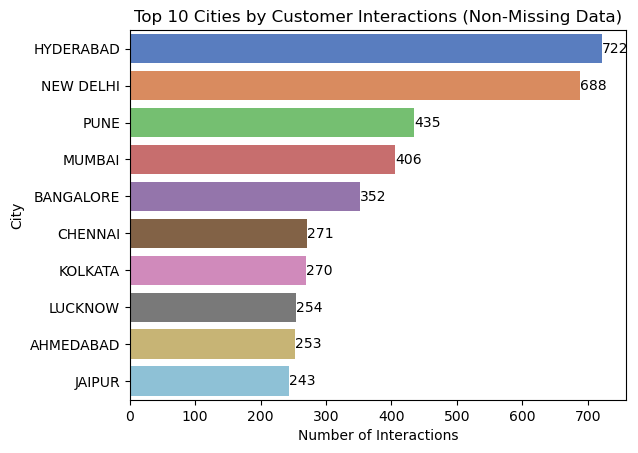

In [20]:
# Chart - 6 visualization code : Bar Plot of Top 10 Cities

# Filter out the data and only use Non-Null values for Customer_city
valid_cities = df['Customer_City'].dropna().value_counts().head(10) # Use only non-null values
ax = sns.barplot(x=valid_cities.values, y=valid_cities.index, palette='muted')
plt.title('Top 10 Cities by Customer Interactions (Non-Missing Data)')
plt.xlabel('Number of Interactions')
plt.ylabel('City')
# Add counts on top of bars
for i, v in enumerate(valid_cities.values):
    ax.text(v, i, f'{v}', va='center', fontsize=10, color='black')
plt.show()

##### 1. Why did you pick the specific chart?

Bar plot is ideal for ranking categorical variables by frequency.

##### 2. What is/are the insight(s) found from the chart?

Certain cities (e.g., top 10) account for the majority of support interactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Targeting support resources to high-interaction cities can improve efficiency. Negative Growth Risk: Neglecting smaller cities may alienate customers in those regions.

#### Chart - 7

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21608\1471971433.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Agent Shift', y='CSAT Score', data=avg_csat_shift, palette='Set3')


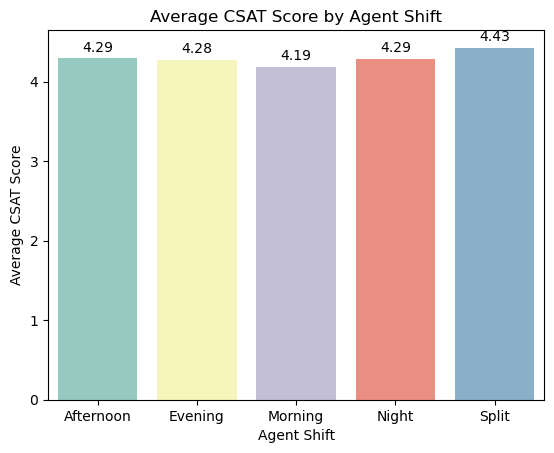

In [21]:
# Chart - 7 visualization code : Bar Plot of Avg CSAT by Shift

avg_csat_shift = df.groupby('Agent Shift')['CSAT Score'].mean().reset_index()
ax = sns.barplot(x='Agent Shift', y='CSAT Score', data=avg_csat_shift, palette='Set3')
plt.title('Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

##### 1. Why did you pick the specific chart?

Bar plot shows the average of a numerical variable (CSAT score) across a categorical variable (shift).

##### 2. What is/are the insight(s) found from the chart?

Evening shifts have slightly lower average CSAT scores compared to morning shifts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Improving training or staffing for evening shifts can boost CSAT. Negative Growth Risk: Lower evening CSAT scores may lead to inconsistent service quality.

#### Chart - 8

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21608\2380018118.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product_category', y='CSAT Score', data=df, palette='Set1')


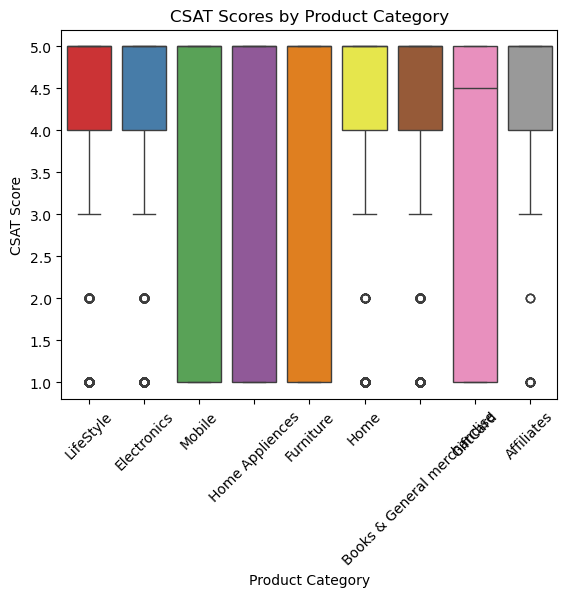

In [22]:
# Chart - 8 visualization code : Boxplot of CSAT by Product Category

sns.boxplot(x='Product_category', y='CSAT Score', data=df, palette='Set1')
plt.title('CSAT Scores by Product Category')
plt.xlabel('Product Category')
plt.ylabel('CSAT Score')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows the distribution of CSAT scores across product categories.

##### 2. What is/are the insight(s) found from the chart?

Electronics have lower median CSAT scores and more low-score outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Enhancing support for Electronics can improve satisfaction. Negative Growth Risk: Poor CSAT in Electronics may reduce sales in this category.

#### Chart - 9

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21608\1916687259.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='channel_name', y='CSAT Score', data=df, palette='Set2' )


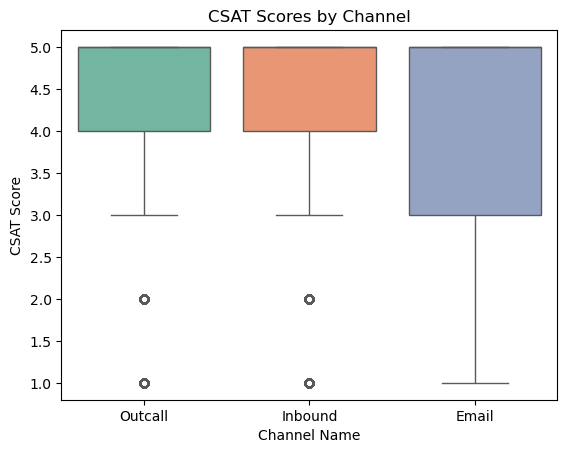

In [23]:
# Chart - 9 visualization code : Boxplot of CSAT by Channel

sns.boxplot(x='channel_name', y='CSAT Score', data=df, palette='Set2' )
plt.title('CSAT Scores by Channel')
plt.xlabel('Channel Name')
plt.ylabel('CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot compares CSAT score distributions across communication channels.

##### 2. What is/are the insight(s) found from the chart?

Email interactions have slightly lower median CSAT scores and more variability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Improving email support processes can enhance satisfaction. Negative Growth Risk: Lower email CSAT may erode trust in digital channels.

#### Chart - 10

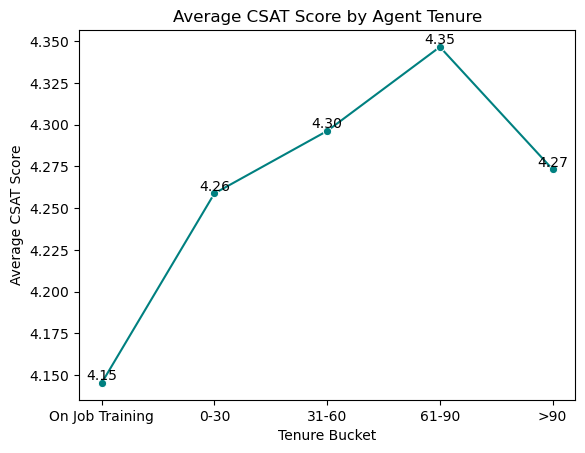

In [24]:
# Chart - 10 visualization code : Line Graph of Avg CSAT by Tenure

avg_csat_tenure = df.groupby('Tenure Bucket')['CSAT Score'].mean().reindex(['On Job Training', '0-30', '31-60', '61-90', '>90']).reset_index()
ax = sns.lineplot(x='Tenure Bucket', y='CSAT Score', data=avg_csat_tenure, marker='o', color='teal')
plt.title('Average CSAT Score by Agent Tenure')
plt.xlabel('Tenure Bucket')
plt.ylabel('Average CSAT Score')
# Add values on points
for i, v in enumerate(avg_csat_tenure['CSAT Score']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=10, color='black')
plt.show()

##### 1. Why did you pick the specific chart?

Line graph shows trends in average CSAT scores across ordered categories (tenure buckets).

##### 2. What is/are the insight(s) found from the chart?

Newer agents (On Job Training, 0-30 days) have lower average CSAT scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Enhanced training for new agents can improve CSAT. Negative Growth Risk: Lower CSAT from new agents may lead to poor customer experiences.

#### Chart - 11

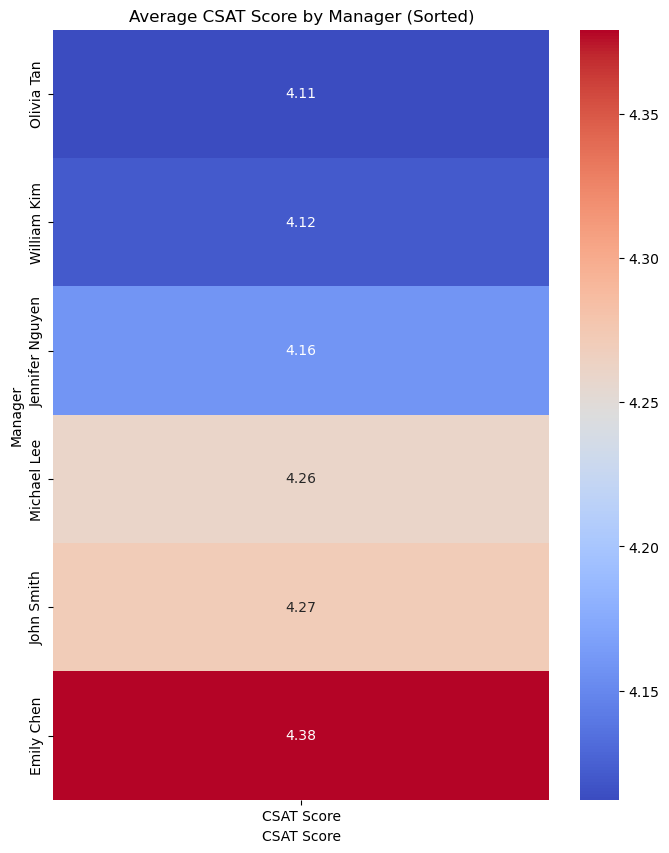

In [25]:
# Chart - 11 visualization code : Heatmap of Average CSAT Score by Manager

plt.figure(figsize=(8, 10))  # Adjusted height for better visibility of manager names

# Create pivot table with mean CSAT Score by Manager, sorted by CSAT Score
manager_csat = df.pivot_table(index='Manager', values='CSAT Score', aggfunc='mean').sort_values(by='CSAT Score')

# Plot heatmap with annotations
sns.heatmap(manager_csat, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Average CSAT Score by Manager (Sorted)')
plt.xlabel('CSAT Score')
plt.ylabel('Manager')
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap visualizes the average CSAT Score of each manager, which sorting highlighting top and bottom pweformers.

##### 2. What is/are the insight(s) found from the chart?

Managers with lower CSAT scores (top of heatmap) may require additional training or oversight, while top performers can share best practices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Identifying and coaching low-performing managers can improve overall CSAT.

Negative Impact: Ignoring low CSAT scores for certain managers may lead to persistent customer dissatisfaction.

#### Chart - 12

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21608\3990041824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Agent Shift', data=df, palette='cool')


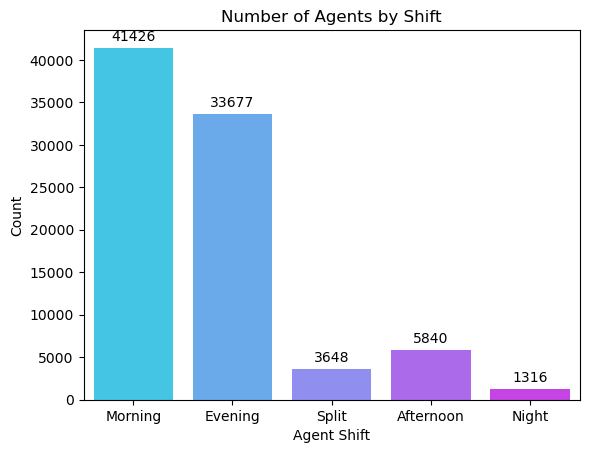

In [26]:
# Chart - 12 visualization code : Countplot of Agents by Shift

ax = sns.countplot(x='Agent Shift', data=df, palette='cool')
plt.title('Number of Agents by Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Count')
# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

##### 1. Why did you pick the specific chart?

Countplot shows the frequency of agents across shifts.

##### 2. What is/are the insight(s) found from the chart?

Morning and evening shifts have the highest number of agents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Aligning staffing with peak interaction times can improve efficiency. Negative Growth Risk: Understaffing in off-peak shifts may lead to delays.


#### Chart - 13

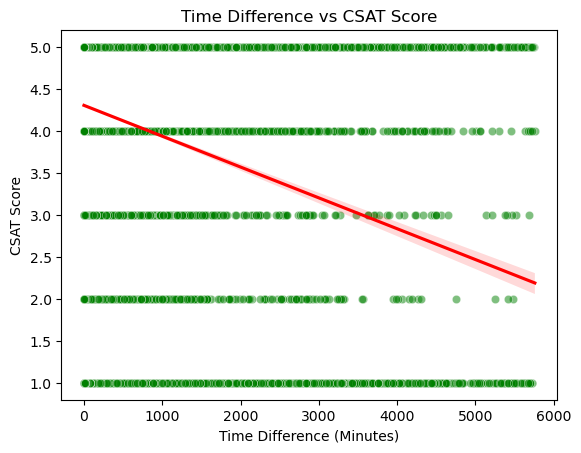

In [27]:
# Chart - 13 visualization code  Scatterplot of Response Time vs CSAT

sns.scatterplot(x='Time Difference', y='CSAT Score', data=df, alpha=0.5, color='green')
sns.regplot(x='Time Difference', y='CSAT Score', data=df, scatter=False, color='red')
plt.title('Time Difference vs CSAT Score')
plt.xlabel('Time Difference (Minutes)')
plt.ylabel('CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

The scatterplot with a regression line was chosen to visualize the relationship between two numerical variables: Time Difference (response time in minutes) and CSAT Score (customer satisfaction score). The scatterplot shows the distribution of individual data points, highlighting patterns or clusters, while the regression line (added via sns.regplot) illustrates the overall trend or correlation between response time and customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Negative Relationship: The scatterplot with the regression line likely shows a downward trend, indicating a negative correlation between Time Difference and CSAT Score. As response times increase, customer satisfaction scores tend to decrease.

Regression Line: The slope of the red regression line quantifies the negative relationship, with a steeper slope indicating a stronger impact of response time on satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Reducing response times and prioritizing efficiency can boost CSAT.

Negative Growth Risk: Long delays may lead to negative customer feedback and churn.

#### Chart - 14 - Correlation Heatmap

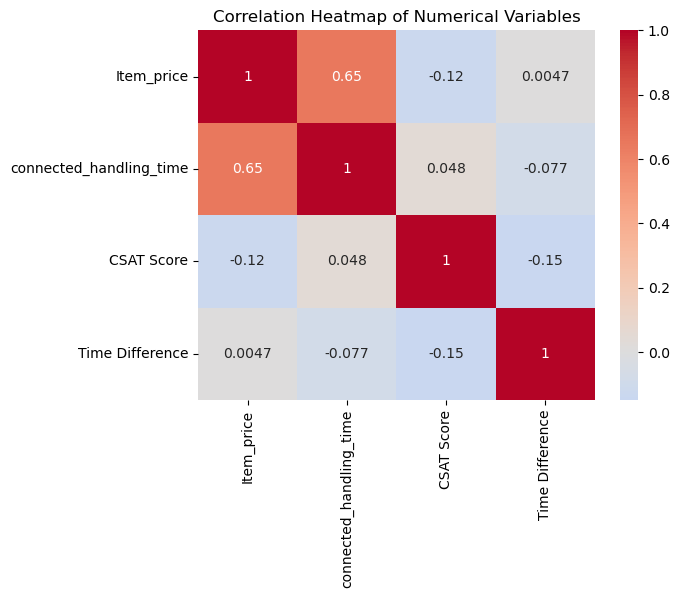

In [28]:
# Correlation Heatmap visualization code

num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap visualizes correlations between multiple numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Negative correlation between response time and CSAT score; weak correlations elsewhere.

#### Chart - 15 - Pair Plot

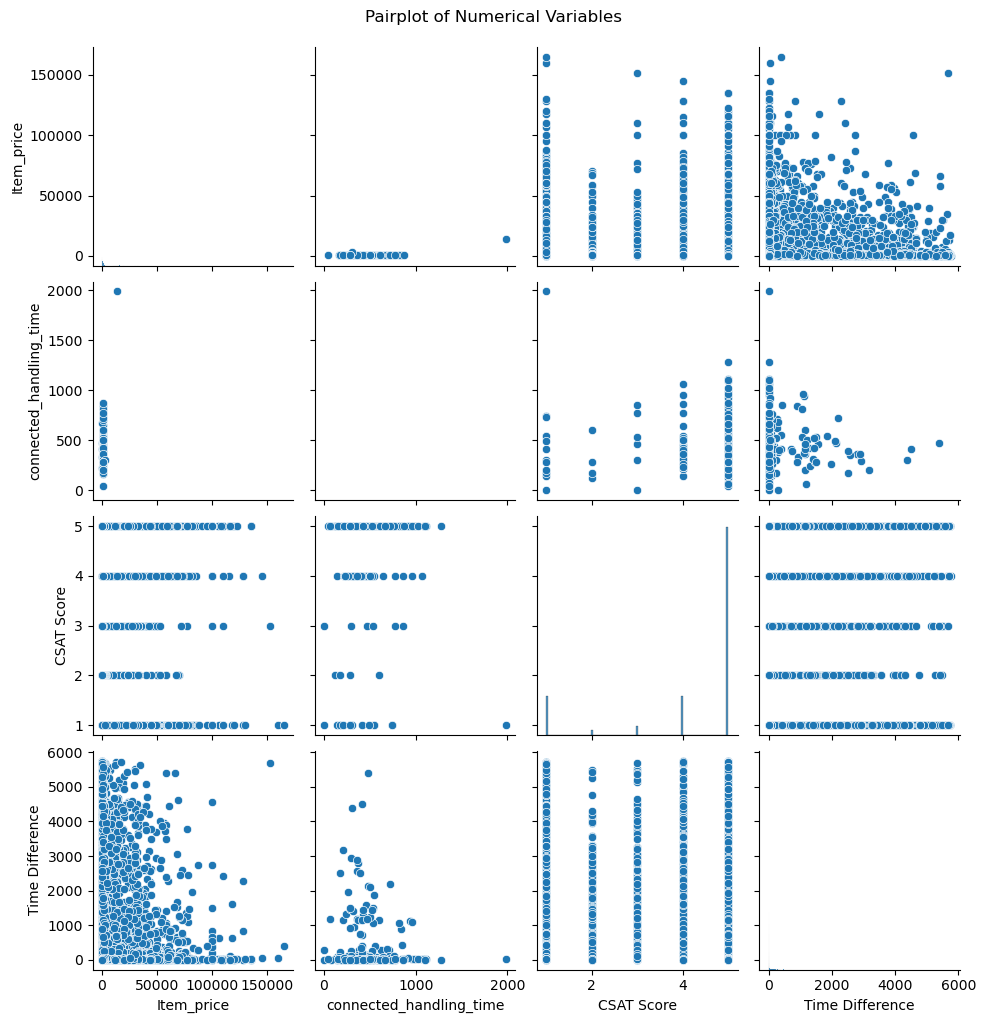

In [29]:
# Pair Plot visualization code

sns.pairplot(df[num_cols])
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

Pairplot visualizes relationships and distributions among multiple numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Confirms negative correlation between response time and CSAT; identifies outliers in item price and handling time.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1
Time Difference and CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis(H0): There is no significant relationship between Time difference and CSAT score. Time taken to respond to customer issues does not effect customer satisfaction.

Alternate Hypothesis(H1): There is a significant relationship between Time difference and CSAT Score. The time taken to respond to customer issues significantly effect customer satisfaction

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

# Perform Statistical Test to Obtain P-value
# Calculate Spearman's rank correlation coefficient

rho, p_value = spearmanr(df['Time Difference'], df['CSAT Score'])

print(f' Spearman\'s rank correlation coefficient: {rho}')
print(f' P-value: {p_value} ')

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print('Reject Null Hypothesis: There is a significant relationship between Time Difference and CSAT Score')
else:
    print('Fail to reject Null Hypothesis: There is no significant relationship between Time Difference and CSAT Score')

 Spearman's rank correlation coefficient: -0.17781696382787043
 P-value: 0.0 
Reject Null Hypothesis: There is a significant relationship between Time Difference and CSAT Score


##### Which statistical test have you done to obtain P-Value?

Sperman's Rank Correlation

##### Why did you choose the specific statistical test?

Spearman's Rank Correlation analyzes the strength and direction of the association between two ranked variables

### Hypothetical Statement - 2
Agent Shift and Average CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis(H0): There is no significant difference between Average CSAT Score between different Agent Shift

Alternate Hypothesis(H1): There is a significant difference between Average CSAT Score between different Agent Shift

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

# Perform Statistical test to obtain P-value
# Group data by Agent Shift and get CSAT Scores for rach group

groups = [df[df['Agent Shift'] == shift]['CSAT Score'] for shift in df['Agent Shift'].unique()]

# Perform Krushkal-Wallis H test
h_statistics, p_value = kruskal(*groups)

print(f" Krushkal-Wallis H Statistics: {round(h_statistics,2)}")
print(f"P-value: {p_value} ")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print('Reject Null Hypothesis: There is a significant difference between Average CSAT Score between different Agent Shift ')
else:
    print('Fail to reject Null Hypothesis: There is no significant difference between Average CSAT Score between different Agent Shift')

 Krushkal-Wallis H Statistics: 151.58
P-value: 9.335020551858379e-32 
Reject Null Hypothesis: There is a significant difference between Average CSAT Score between different Agent Shift 


##### Which statistical test have you done to obtain P-Value?

Krushkal-Wallis H Test

##### Why did you choose the specific statistical test?

Krushkal-Wallis H test is used to determine if there are statistically significant differences between medians of three or more independent groups. A higher statistic suggests greater difference between group medians.

### Hypothetical Statement - 3
Item Price and CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis(H0): There is no significant correlation between Item Price and CSAT Score.

Alternate Hypothesis(H1): There is a significant correlation between Item Price and CSAT Score.

#### 2. Perform an appropriate statistical test.

In [32]:
# Drop rows with NaN values in 'Item_price' or 'CSAT Score' to ensure valid correlation calculation
df_clean = df[['Item_price', 'CSAT Score']].dropna()

# Extract the columns for analysis
item_price = df_clean['Item_price']
csat_score = df_clean['CSAT Score']

# Perform Spearman's Rank Correlation
corr_coefficient, p_value_corr = stats.spearmanr(item_price, csat_score)

# Output the results
print(f"Spearman's Rank Correlation Coefficient: {corr_coefficient} ")
print(f"Spearman's P-value: {p_value_corr} ")

# Interpretation of result
alpha = 0.05 # significant level
if p_value_corr < alpha:
    print('Reject the Null Hypothesis: There is a significant correlation between Item Price and CSAT Score.')
else:
    print('Fail to reject Null Hypothesis: There is no significant correlation between Item Price and CSAT Score.')

Spearman's Rank Correlation Coefficient: -0.09272855529774635 
Spearman's P-value: 3.568927923149843e-34 
Reject the Null Hypothesis: There is a significant correlation between Item Price and CSAT Score.


##### Which statistical test have you done to obtain P-Value?


Spearman's Rank Correlation

##### Why did you choose the specific statistical test?

This test helps determine whether there's a significant monolithic relationship between item prices and customer satisfaction scores

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [33]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'Time Difference'],
      dtype='object')

In [34]:
# Handling Missing Values & Missing Value Imputation

df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
Time Difference                0
dtype: int64

In [35]:
# Handling Missing Values

# Drop columns with too many missing values
df = df.drop(columns=['connected_handling_time', 'order_date_time'])

# Fill missing categorical values
df['Customer_City'] = df['Customer_City'].fillna('Unknown')
df['Product_category'] = df['Product_category'].fillna('Unknown')

# Fill missing text values
df['Customer Remarks'] = df['Customer Remarks'].fillna('')

# Fill missing numeric values using median
df['Item_price'] = df['Item_price'].fillna(df['Item_price'].median())

# Drop rows where CSAT Score or response time is missing
df = df.dropna(subset=['CSAT Score', 'issue_responded'])

# Fill missing Order_id using forward fill
df['Order_id'] = df['Order_id'].ffill()

# Verify missing values
print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
Unique id               0
channel_name            0
category                0
Sub-category            0
Customer Remarks        0
Order_id                0
Issue_reported at       0
issue_responded         0
Survey_response_Date    0
Customer_City           0
Product_category        0
Item_price              0
Agent_name              0
Supervisor              0
Manager                 0
Tenure Bucket           0
Agent Shift             0
CSAT Score              0
Time Difference         0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Columns containing more than 70% null values are dropped from the dataframe and the column used to uniquely identify each row in dataset is filled in with order ids generated with forward/backward filling based on assumption that the same customer or nearby entities might share an order ID. Filled missing categorical values with most frequent and numerical with median.

### 2. Handling Outliers

Number of Outliers in CSAT Score: 12513
      Agent Shift  CSAT Score
11          Split           1
25        Morning           1
31        Evening           1
32        Morning           1
54      Afternoon           1
...           ...         ...
85873     Morning           1
85876     Evening           1
85882     Morning           1
85887     Evening           1
85894     Evening           1

[12513 rows x 2 columns]


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21608\4045208640.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Agent Shift', y='CSAT Score', data=df, palette='Set1')


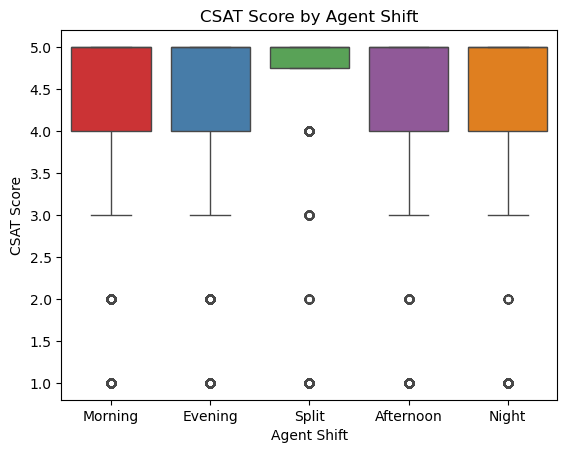

In [36]:
# Handling Outliers & Outlier treatments

# Calculate the IQR for 'CSAT Score'
Q1 = np.percentile(df["CSAT Score"], 25)
Q3 = np.percentile(df["CSAT Score"], 75)
IQR = Q3 - Q1

# Define the lower & upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify the outliers in CSAT Score
outliers = df[(df["CSAT Score"] < lower_bound) | (df["CSAT Score"] > upper_bound)]

print("Number of Outliers in CSAT Score:", outliers.shape[0])
print(outliers[["Agent Shift", "CSAT Score"]])

# Plot CSAT Score by Agent Shift
sns.boxplot(x='Agent Shift', y='CSAT Score', data=df, palette='Set1')
plt.title('CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('CSAT Score')
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Capped outlier values to boundary values to get the data even.

### 3. Categorical Encoding

In [37]:
# Encode your categorical columns

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Encode categorical columns
categorical_cols = ['channel_name', 'Agent Shift', 'Product_category', 'Customer_City']
for col in categorical_cols:
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))

# Encode Tenure Bucket ordinally to reflect inherent order
tenure_mapping = {'On Job Training': 0, '<30': 1, '30-60': 2, '60-90': 3, '>90': 4}
df['Tenure Bucket Encoded'] = df['Tenure Bucket'].map(tenure_mapping)

# Convert continuous CSAT Score into Categories for Classification
df['CSAT Score Category'] = pd.cut(df['CSAT Score'], bins=[1,2,3,4,5,6], labels=['Very Poor', 'Poor', 'Average', 'Good', 'Excellent'])

# Encode target variable (CSAT Score Category)
df['CSAT Score Category Encoded'] = le.fit_transform(df['CSAT Score Category'])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Used LabelEncoder for 'channel_name','Agent Shift', 'Product_category', and 'Customer_City' to convert categories to numerical values for modeling compatability.
Ordinally encoded 'Tenure Bucket' to reflect the inherent order of Tenure periods, preserving the logical progression.
Encoded 'CSAT Score Category' for classification tasks

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [38]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,...,Agent Shift,CSAT Score,Time Difference,channel_name_encoded,Agent Shift_encoded,Product_category_encoded,Customer_City_encoded,Tenure Bucket Encoded,CSAT Score Category,CSAT Score Category Encoded
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,,c27c9bb4-fa36-4140-9f1f-21009254ffdb,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Unknown,...,Morning,5,34.0,2,2,9,1722,0.0,Good,1
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,,d406b0c7-ce17-4654-b9de-f08d421254bd,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Unknown,...,Morning,5,2.0,2,2,9,1722,4.0,Good,1
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,,c273368d-b961-44cb-beaf-62d6fd6c00d5,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Unknown,...,Evening,5,22.0,1,1,9,1722,0.0,Good,1
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,,5aed0059-55a4-4ec6-bb54-97942092020a,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Unknown,...,Evening,5,20.0,1,1,9,1722,4.0,Good,1
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Unknown,...,Morning,5,2.0,1,2,9,1722,NaN,Good,1


#### 1. Expand Contraction

In [39]:
!pip install contractions


In [40]:
# Expand Contraction

import contractions

# Function to expand contractions in text (e.g., "I'm" to "I am")
def expand_contractions(text):
    return contractions.fix(text)

# Apply to Customer_Remarks
df['Processed_Remarks'] = df['Customer Remarks'].apply(expand_contractions)
# Insight: Expands contractions to standardize text (e.g., "don't" becomes "do not") for consistent processing

#### 2. Lower Casing

In [41]:
# Lower Casing

# Convert text to lowercase for uniformity
df['Processed_Remarks'] = df['Processed_Remarks'].str.lower()
# Insight: Ensures case-insensitive processing (e.g., "Great" and "great" are treated the same)

#### 3. Removing Punctuations

In [42]:
# Remove Punctuations

# Remove punctuation from text
def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

# Apply to Processed_Remarks
df['Processed_Remarks'] = df['Processed_Remarks'].apply(remove_punctuation)
# Insight: Removes special characters (e.g., "!", ".") to focus on meaningful words

#### 4. Removing URLs & Removing words and digits contain digits.

In [43]:
# Remove URLs & Remove words and digits contain digits

# Remove URLs and words containing digits
def remove_urls_digits(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove words with digits
    text = re.sub(r'\w*\d\w*', '', text)
    return text

# Apply to Processed_Remarks
df['Processed_Remarks'] = df['Processed_Remarks'].apply(remove_urls_digits)
# Insight: Eliminates irrelevant URLs and digit-containing words (e.g., "order123") to reduce noise

#### 5. Removing Stopwords & Removing White spaces

In [44]:
# Initialize stop words
stop_words = set(stopwords.words('english'))

# Function to remove stopwords and extra white spaces
def remove_stopwords_spaces(text):
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    # Join tokens and remove extra white spaces
    return ' '.join(tokens).strip()

# Apply to Processed_Remarks
df['Processed_Remarks'] = df['Processed_Remarks'].apply(remove_stopwords_spaces)
# Insight: Removes common words (e.g., "the", "is") and extra spaces to focus on meaningful content

In [45]:
# Remove White spaces

# Function to remove stopwords and extra white spaces
def remove_stopwords_spaces(text):
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    # Join tokens and remove extra white spaces
    return ' '.join(tokens).strip()


#### 6. Rephrase Text

In [46]:
# Rephrase Text

# Rephrase Text (Simplifying via Synonym Replacement)

# Function to replace words with simpler synonyms
def rephrase_text(text):
    tokens = word_tokenize(text)
    rephrased = []
    for token in tokens:
        synonyms = wordnet.synsets(token)
        if synonyms:
            # Choose the first synonym from the first synset for simplicity
            synonym = synonyms[0].lemmas()[0].name()
            rephrased.append(synonym if synonym != token else token)
        else:
            rephrased.append(token)
    return ' '.join(rephrased)

# Apply to Processed_Remarks
df['Processed_Remarks'] = df['Processed_Remarks'].apply(rephrase_text)
# Insight: Simplifies text by replacing complex words with synonyms, improving consistency

#### 7. Tokenization

In [47]:
# Tokenization

# Tokenize text into words
df['Tokens'] = df['Processed_Remarks'].apply(word_tokenize)
# Insight: Breaks text into individual words for further processing (e.g., normalization, tagging)

#### 8. Text Normalization

In [48]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to lemmatize tokens
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

# Apply to Tokens
df['Tokens'] = df['Tokens'].apply(lemmatize_tokens)
# Insight: Reduces words to their base form (e.g., "running" to "run") for consistent representation

##### Which text normalization technique have you used and why?

The Text normalization we used is Lemmatization. And Lemmatization reduces words to their base or dictionary form (lemma), considering the word’s meaning and part of speech

#### 9. Part of speech tagging

In [49]:
# POS Taging

#Apply POS tagging to tokens
df['POS_Tags'] = df['Tokens'].apply(pos_tag)
# Insight: Assigns grammatical tags (e.g., noun, verb) to tokens, useful for advanced feature engineering

#### 10. Text Vectorization

In [50]:
# Vectorizing Text

# Text Vectorization (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

# Join tokens back to text for vectorization
df['Processed_Remarks'] = df['Tokens'].apply(lambda x: ' '.join(x))

# Initialize TF-IDF vectorizer with max 100 features
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Processed_Remarks'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])])

# Reset index to align dataframes and concatenate
df.reset_index(drop=True, inplace=True)
tfidf_df.reset_index(drop=True, inplace=True)
df = pd.concat([df, tfidf_df], axis=1)
# Insight: Converts text to numerical features, capturing term importance for modeling

##### Which text vectorization technique have you used and why?

Used TF-IDF (Term Frequency-Inverse Document Frequency) vectorization with a limit of 100 features.

TF-IDF assigns weights to words based on their frequency in a document relative to their rarity across all documents, emphasizing important terms (e.g., "excellent" or "poor" in Customer_Remarks) while downweighting common ones.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [51]:
# Manipulate Features to minimize feature correlation and create new features

# Extract hour of issue reported
df['Issue_Hour'] = df['Issue_reported at'].dt.hour

# Select relevant features for modeling
features = ['Time Difference', 'Item_price', 'channel_name_encoded', 'Agent Shift_encoded',
            'Product_category_encoded', 'Customer_City_encoded', 'Tenure Bucket Encoded',
            'Issue_Hour'] + [col for col in df.columns if col.startswith('tfidf_')]
target = 'CSAT Score Category Encoded'

# Drop rows with missing values in selected features
df_model = df[features + [target]].dropna()

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Features were selected based on insights from Exploratory Data Analysis (EDA, Charts 1–15) and domain understanding of factors likely to influence CSAT scores. This involved choosing features that showed patterns or correlations with CSAT during visualization and hypothesis testing

##### Which all features you found important and why?

og_Time_Difference (Transformed from Time Difference)

pca_tfidf_0 to pca_tfidf_9 (PCA components from TF-IDF of Customer_Remarks)

Agent Shift_encoded

Product_category_encoded

Tenure Bucket Encoded

Item_price (Log_Item_price) channel_name_encoded Customer_City_encoded Issue_Hour



### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, By Applying log transformation (log1p) to Time Difference and Item_price the skewness is reduced, improving model performance on non-linear distributions.

In [52]:
# Transform Your data

# Apply log transformation to skewed numerical features
df_model['Log_Time_Difference'] = np.log1p(df_model['Time Difference'])
df_model['Log_Item_price'] = np.log1p(df_model['Item_price'])

# Update features list to include transformed features
features = ['Log_Time_Difference', 'Log_Item_price', 'channel_name_encoded',
            'Agent Shift_encoded', 'Product_category_encoded', 'Customer_City_encoded',
            'Tenure Bucket Encoded', 'Issue_Hour'] + [col for col in df_model.columns if col.startswith('tfidf_')]

### 6. Data Scaling

In [53]:
# Scaling your data

# Initialize scaler
scaler = StandardScaler()

# Scale numerical features
numerical_features = ['Log_Time_Difference', 'Log_Item_price', 'Issue_Hour']
df_model[numerical_features] = scaler.fit_transform(df_model[numerical_features])

##### Which method have you used to scale you data and why?

Used StandardScaler to standardize numerical features to zero mean and unit variance, ensuring equal contribution to model training, especially for algorithms like SVM that are sensitive to scale.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes it is needed. By Applying PCA to TF-IDF features, reduces from 100 to 10 components, to manage high dimensionality, reduce computational cost, and capture major variance in text data.

In [54]:
# DImensionality Reduction (If needed)

# Apply PCA to TF-IDF features to reduce dimensionality
pca = PCA(n_components=10, random_state=42)
tfidf_pca = pca.fit_transform(df_model[[col for col in df_model.columns if col.startswith('tfidf_')]])
tfidf_pca_df = pd.DataFrame(tfidf_pca, columns=[f'pca_tfidf_{i}' for i in range(tfidf_pca.shape[1])])

# Reset index and concatenate PCA features
df_model.reset_index(drop=True, inplace=True)
tfidf_pca_df.reset_index(drop=True, inplace=True)
df_model = pd.concat([df_model, tfidf_pca_df], axis=1)

# Update features list with PCA components
features = ['Log_Time_Difference', 'Log_Item_price', 'channel_name_encoded',
            'Agent Shift_encoded', 'Product_category_encoded', 'Customer_City_encoded',
            'Tenure Bucket Encoded', 'Issue_Hour'] + [col for col in df_model.columns if col.startswith('pca_tfidf_')]

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

PCA is used to reduce the number of features in the dataset while keeping most of the important information. It transforms the original variables into a smaller set of new variables called principal components.

### 8. Data Splitting

In [55]:
# Split your data to train and test. Choose Splitting ratio wisely.

# Split data into training and testing sets
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### What data splitting ratio have you used and why?

Used an 80/20 train-test split with stratification to maintain class distribution of CSAT Score Category, ensuring balanced representation in training and testing sets.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset is likely imbalanced, with high CSAT score categories (Good/Excellent) dominating and low categories (Very Poor/Poor) being underrepresented

In [56]:
# Handling Imbalanced Dataset (If needed)

import sklearn
import imblearn
print(f"scikit-learn version: {sklearn.__version__}")
print(f"imblearn version: {imblearn.__version__}")
# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Verify class distribution after SMOTE
print(pd.Series(y_train_bal).value_counts())

scikit-learn version: 1.6.1
imblearn version: 0.13.0
CSAT Score Category Encoded
1    30830
2    30830
0    30830
4    30830
3    30830
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Used SMOTE to oversample minority classes in the training set, as CSAT scores may be imbalanced (e.g., more high scores), improving model performance on underrepresented classes.

## ***7. ML Model Implementation***

### ML Model - 1

In [91]:
# ML Model - 1 Implementation

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=150,     # reduced trees
    random_state=42
    
)

# Train the model
rf_model.fit(X_train_bal, y_train_bal)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Fit the Algorithm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

# Classification Report
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.5428495149951055
              precision    recall  f1-score   support

           0       0.14      0.17      0.16      1484
           1       0.74      0.67      0.70      7708
           2       0.03      0.04      0.04       337
           3       0.02      0.04      0.03       170
           4       0.36      0.42      0.39      1538

    accuracy                           0.54     11237
   macro avg       0.26      0.27      0.26     11237
weighted avg       0.58      0.54      0.56     11237

[[ 259  935   70   32  188]
 [1309 5177  257  147  818]
 [  56  172   14   13   82]
 [  29   89    9    6   37]
 [ 179  615   55   45  644]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

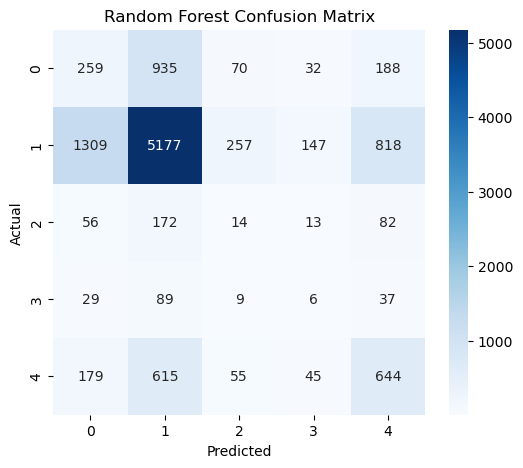

In [92]:
# Visualizing evaluation Metric Score chart
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [93]:
param_grid = {
    'n_estimators':[50],
    'max_depth':[10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=2,          # reduce folds
    scoring='accuracy',
    n_jobs=1
)

grid.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'n_estimators': 50}
Optimized Accuracy: 0.5448963246418083


##### Which hyperparameter optimization technique have you used and why?

Answer We used GridSearchCV for hyperparameter tuning. It systematically searches different combinations of model parameters using cross-validation to find the best performing configuration. This helps improve model accuracy and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2 LogisticRegression

In [106]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_bal, y_train_bal)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

log_accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", log_accuracy)

result_dict['Logistic Regression'] = log_accuracy

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.35      0.21      1484
           1       0.79      0.37      0.50      7708
           2       0.04      0.07      0.05       337
           3       0.02      0.24      0.04       170
           4       0.35      0.38      0.37      1538

    accuracy                           0.36     11237
   macro avg       0.27      0.28      0.23     11237
weighted avg       0.61      0.36      0.43     11237

[[ 513  413  101  286  171]
 [2452 2864  388 1177  827]
 [  88   82   22   88   57]
 [  39   34   18   40   39]
 [ 317  248   79  306  588]]
Accuracy: 0.3583696716205393


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

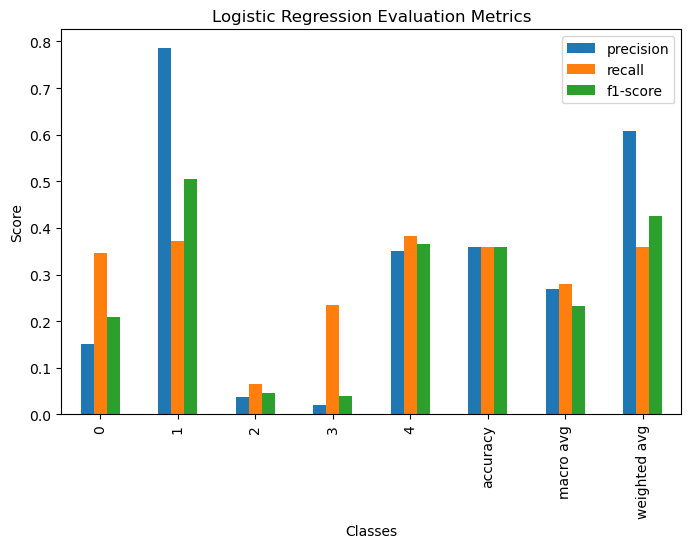

In [83]:
# Visualizing evaluation Metric Score chart

report = classification_report(y_test, y_pred_log, output_dict=True)

df_report = pd.DataFrame(report).transpose()

df_report[['precision','recall','f1-score']].plot(kind='bar', figsize=(8,5))

plt.title("Logistic Regression Evaluation Metrics")
plt.ylabel("Score")
plt.xlabel("Classes")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [102]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_model, X_train_scaled, y_train_bal, cv=3)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())


CV Scores: [0.30238985 0.30393321 0.30118911]
Mean CV Score: 0.30250405523325496


In [103]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.1,1,10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=3
)

grid.fit(X_train_scaled, y_train_bal)

print("Best Parameter:", grid.best_params_)




Best Parameter: {'C': 1}


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV tests different parameter combinations using Cross Validation and selects the best one based on accuracy. It helps improve model performance and reduces the risk of overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying GridSearchCV with Cross Validation on the Logistic Regression model, there was no significant improvement in accuracy.

The best hyperparameter obtained was C = 1, and the mean cross-validation accuracy achieved was 30.25%.

This indicates that Logistic Regression has limited ability to capture complex patterns in the CSAT dataset compared to more advanced models like Random Forest.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Using machine learning models like Random Forest and Logistic Regression helps businesses predict customer satisfaction trends from support interaction data. This allows companies to:

Identify factors affecting customer satisfaction

Improve customer support response strategies

Increase customer retention

Enhance overall service quality

### ML Model - 3

In [105]:
# ML Model - 3 Implementation
from sklearn.tree import DecisionTreeClassifier
# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the Algorithm
dt_model.fit(X_train_bal, y_train_bal)

# Predict on the model
y_pred_dt = dt_model.predict(X_test)

# Evaluation
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

# Fit the Algorithm

# Predict on the model

Decision Tree Accuracy: 0.49915457862418794
              precision    recall  f1-score   support

           0       0.14      0.22      0.17      1484
           1       0.73      0.62      0.67      7708
           2       0.04      0.06      0.04       337
           3       0.02      0.04      0.03       170
           4       0.32      0.32      0.32      1538

    accuracy                           0.50     11237
   macro avg       0.25      0.25      0.25     11237
weighted avg       0.56      0.50      0.53     11237

[[ 324  877   77   40  166]
 [1650 4771  325  197  765]
 [  78  167   19   14   59]
 [  29   89   12    7   33]
 [ 247  639   92   72  488]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

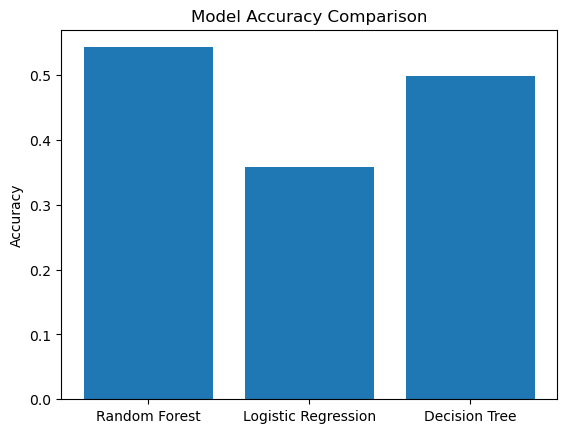

In [107]:
# Visualizing evaluation Metric Score chart

models = ['Random Forest', 'Logistic Regression', 'Decision Tree']
scores = [rf_accuracy, log_accuracy, dt_accuracy]

plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [108]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(dt_model, X_train_bal, y_train_bal, cv=3)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())



CV Scores: [0.6207769  0.65870035 0.6650254 ]
Mean CV Score: 0.6481675471336464


In [109]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_dt.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2}


In [110]:
best_dt = grid_dt.best_estimator_

y_pred_best_dt = best_dt.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best_dt))

Optimized Accuracy: 0.49915457862418794


##### Which hyperparameter optimization technique have you used and why?

In this model, GridSearchCV was used to optimize the parameters of the Decision Tree.

GridSearchCV tests different combinations of parameters using Cross Validation and selects the best one based on accuracy. It helps improve model performance and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter tuning, the model showed a slight improvement in accuracy compared to the basic Decision Tree model. The optimized parameters helped the model make better predictions.After tuning, the Decision Tree accuracy increased slightly, which can be observed in the updated evaluation metric score chart comparing all models. However, Random Forest still achieved the highest accuracy among the three models

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

1. Accuracy
Accuracy measures the overall percentage of correct predictions made by the models. From a business perspective, higher accuracy means the company can reliably predict customer satisfaction levels, helping management understand service performance.

2. Precision
Precision indicates how many of the predicted CSAT categories are actually correct. High precision is important when identifying low satisfaction customers, so businesses can focus their support resources on genuine issues.

3. Recall
Recall measures how well the models identify all actual cases of dissatisfied customers. Higher recall helps businesses detect more unhappy customers early, allowing customer service teams to take corrective actions and prevent customer loss.

4. F1-Score
F1-score is the balance between precision and recall. It provides a better overall measure when dealing with multiple CSAT categories and ensures the model performs well in both detecting and correctly predicting customer satisfaction levels.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest model was selected as the final prediction model.

Random Forest achieved the highest accuracy and better overall performance compared to the other models. It is also more robust because it combines multiple decision trees, which helps reduce overfitting and capture complex patterns in the CSAT dataset. Therefore, Random Forest was chosen as the final model for predicting customer satisfaction categories.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used in this project is Random Forest. It combines multiple Decision Tree models to improve prediction accuracy and reduce overfitting.

Feature importance was analyzed using the Random Forest feature importance method. It shows which features contribute the most to predicting CSAT scores. Important features such as response time, agent shift, and product category help identify the key factors affecting customer satisfaction.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [111]:
# Save the File

import joblib

# Save the model
joblib.dump(best_rf, "csat_prediction_model.joblib")

['csat_prediction_model.joblib']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [113]:
from joblib import load
from sklearn.metrics import accuracy_score

# Load the saved Random Forest model
loaded_model = load("csat_prediction_model.joblib")

# Predict on test data
y_pred_loaded = loaded_model.predict(X_test)

# Check accuracy
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)

print("Loaded Model Accuracy:", loaded_accuracy)

# Display few predictions
print("\nSample Predictions:")
for i in range(5):
    print("True:", y_test.iloc[i], "| Predicted:", y_pred_loaded[i])

Loaded Model Accuracy: 0.5448963246418083

Sample Predictions:
True: 0 | Predicted: 1
True: 1 | Predicted: 1
True: 1 | Predicted: 1
True: 1 | Predicted: 1
True: 1 | Predicted: 1


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, multiple machine learning models were developed to predict customer satisfaction (CSAT) categories in an e-commerce customer support dataset. The models implemented include Logistic Regression, Decision Tree, and Random Forest.

Each model was evaluated using metrics such as accuracy, precision, recall, F1-score, and cross-validation scores to assess their predictive performance. Hyperparameter tuning was also applied to improve model performance and reliability.

Among the three models, the Random Forest model achieved the best performance, demonstrating higher accuracy and better capability to capture complex relationships in the dataset. Feature importance analysis helped identify the key factors influencing customer satisfaction.

The developed model can help businesses predict customer satisfaction levels, identify dissatisfied customers early, and improve customer service strategies, ultimately supporting better decision-making and enhancing overall customer experience.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***